In [2]:
import pandas as pd

# Load SOL CSV
sol_df = pd.read_csv(r'feature_datasets\SOL_features.csv', parse_dates=True, index_col=0)

# Define X and y
sol_y = sol_df['Close'].shift(-1)          # next-day close price
sol_X = sol_df.drop(columns=['Close'])     # all other features

# Drop last row (y will be NaN)
sol_X = sol_X.iloc[:-1]
sol_y = sol_y.iloc[:-1]

# Optional: check shapes
print("SOL X shape:", sol_X.shape)
print("SOL y shape:", sol_y.shape)

SOL X shape: (915, 29)
SOL y shape: (915,)


## Basis split 

In [3]:
# 70% train / 30% test split (time-based)
split_idx = int(len(sol_X) * 0.7)

sol_X_train = sol_X.iloc[:split_idx].values
sol_X_test  = sol_X.iloc[split_idx:].values

sol_y_train = sol_y.iloc[:split_idx].values
sol_y_test  = sol_y.iloc[split_idx:].values

print("ETH X_train shape:", sol_X_train.shape)
print("ETH X_test shape:", sol_X_test.shape)
print("ETH y_train shape:", sol_y_train.shape)
print("ETH y_test shape:", sol_y_test.shape)

ETH X_train shape: (640, 29)
ETH X_test shape: (275, 29)
ETH y_train shape: (640,)
ETH y_test shape: (275,)


In [4]:
sol_test_dates = sol_df.index[-len(sol_X_test):]

In [5]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# Initialize scaler
scaler = MinMaxScaler()

# Fit on TRAIN only
sol_X_train_scaled = scaler.fit_transform(sol_X_train)

# Transform TEST using the same scaler
sol_X_test_scaled = scaler.transform(sol_X_test)

# Check shapes
print("Scaled X_train shape:", sol_X_train_scaled.shape)
print("Scaled X_test shape:", sol_X_test_scaled.shape)

Scaled X_train shape: (640, 29)
Scaled X_test shape: (275, 29)


In [6]:
# Initialize scaler for y
y_scaler = MinMaxScaler()

# Scale training target
sol_y_train_scaled = y_scaler.fit_transform(sol_y_train.reshape(-1,1)).flatten()

# Scale test target
sol_y_test_scaled = y_scaler.transform(sol_y_test.reshape(-1,1)).flatten()


In [7]:
def create_sequences(X, y, time_steps=30):
    X_seq, y_seq = [], []
    for i in range(len(X) - time_steps):
        X_seq.append(X[i:i+time_steps])
        y_seq.append(y[i+time_steps])  # the next day after the sequence
    return np.array(X_seq), np.array(y_seq)

# Create sequences for SOL using scaled target
sol_X_train_seq, sol_y_train_seq = create_sequences(sol_X_train_scaled, sol_y_train_scaled, time_steps=30)
sol_X_test_seq, sol_y_test_seq = create_sequences(sol_X_test_scaled, sol_y_test_scaled, time_steps=30)

# Check shapes
print("SOL X_train_seq shape:", sol_X_train_seq.shape)
print("SOL y_train_seq shape:", sol_y_train_seq.shape)
print("SOL X_test_seq shape:", sol_X_test_seq.shape)
print("SOL y_test_seq shape:", sol_y_test_seq.shape)

SOL X_train_seq shape: (610, 30, 29)
SOL y_train_seq shape: (610,)
SOL X_test_seq shape: (245, 30, 29)
SOL y_test_seq shape: (245,)


### Model training

In [8]:
from Bi_LSTM import BiLSTM, train_model, predict_model

In [9]:
# Get number of features from the sequences
input_size = sol_X_train_seq.shape[2]

# Initialize Bi-LSTM model
model = BiLSTM(input_size=input_size)


In [10]:
model = train_model(model, sol_X_train_seq, sol_y_train_seq, epochs=50, batch_size=32, lr=0.001
)


Epoch [10/50], Loss: 0.005541
Epoch [20/50], Loss: 0.001288
Epoch [30/50], Loss: 0.006359
Epoch [40/50], Loss: 0.003094
Epoch [50/50], Loss: 0.001001


In [11]:
sol_preds = predict_model(model, sol_X_test_seq)

# check
print("Predictions shape:", sol_preds.shape)
print("First 10 predictions:", sol_preds[:10])

Predictions shape: (245, 1)
First 10 predictions: [[0.06656276]
 [0.05887822]
 [0.05542487]
 [0.04981787]
 [0.04851171]
 [0.04634508]
 [0.04593756]
 [0.04497692]
 [0.03047785]
 [0.03568294]]


In [12]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Inverse scale predictions
sol_preds_actual = y_scaler.inverse_transform(sol_preds.reshape(-1,1))

# Skip first 30 because of 30-day sequence
sol_y_test_actual = sol_y_test[30:].reshape(-1,1)

# Calculate metrics
mse = mean_squared_error(sol_y_test_actual, sol_preds_actual)
rmse = np.sqrt(mse)
mae = mean_absolute_error(sol_y_test_actual, sol_preds_actual)
r2 = r2_score(sol_y_test_actual, sol_preds_actual)
mape = np.mean(np.abs((sol_y_test_actual - sol_preds_actual) / sol_y_test_actual)) * 100

print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R2 Score: {r2:.4f}")
print(f"MAPE: {mape:.2f}%")

MSE: 57.87
RMSE: 7.61
MAE: 6.05
R2 Score: 0.8926
MAPE: 19.32%


In [13]:
sol_preds_actual = y_scaler.inverse_transform(sol_preds.reshape(-1,1))

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# Skip first 30 because of sequence
dates_seq = sol_df.index[-len(sol_X_test):][30:]  # test dates aligned with sequences
actual_seq = sol_y_test[30:]                      # actual prices aligned
pred_seq = sol_preds_actual                       # predicted prices aligned

# Create DataFrame
df_plot = pd.DataFrame({
    "Date": dates_seq,
    "Actual": actual_seq,
    "Predicted": pred_seq.flatten()
})

df_plot.set_index("Date", inplace=True)
df_plot.head()

,Actual,Predicted
Date,,
2023-05-02,22.264978,26.244717
2023-05-03,22.218002,24.329098
2023-05-04,21.730349,23.468235
2023-05-05,22.826111,22.070509
2023-05-06,21.974262,21.744905


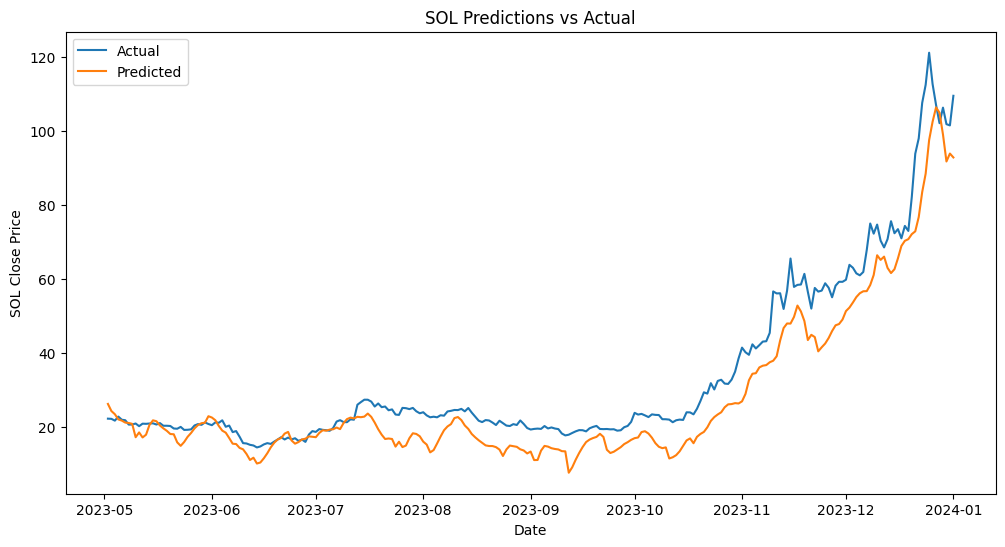

In [15]:
plt.figure(figsize=(12,6))
plt.plot(df_plot["Actual"], label="Actual")
plt.plot(df_plot["Predicted"], label="Predicted")
plt.xlabel("Date")
plt.ylabel("SOL Close Price")
plt.title("SOL Predictions vs Actual")
plt.legend()
plt.show()

## Each year 70% split

In [16]:
# Get unique years from your DataFrame index
years = sol_df.index.year.unique()
print("Years in dataset:", years)

Years in dataset: Index([2021, 2022, 2023, 2024], dtype='int32', name='Date')


In [17]:
X_train_list = []
y_train_list = []

In [18]:
for year in years:
    # Filter data for this year
    sol_year = sol_df[sol_df.index.year == year]

    # Calculate split index for 70%
    split_idx = int(len(sol_year) * 0.7)

    # Take first 70% as training
    X_train_year = sol_year.iloc[:split_idx, 1:].values  # all features except target column
    y_train_year = sol_year.iloc[:split_idx, 0].values   # target column (e.g., next-day Close)

    # Append to lists
    X_train_list.append(X_train_year)
    y_train_list.append(y_train_year)

    print(f"Year {year}: {len(X_train_year)} train samples")

Year 2021: 129 train samples
Year 2022: 255 train samples
Year 2023: 255 train samples
Year 2024: 0 train samples


In [19]:
import numpy as np

# Stack all years’ train sets
X_train_combined = np.vstack(X_train_list)
y_train_combined = np.hstack(y_train_list)

print("Combined X_train shape:", X_train_combined.shape)
print("Combined y_train shape:", y_train_combined.shape)


Combined X_train shape: (639, 29)
Combined y_train shape: (639,)


In [20]:
X_test_list = []
y_test_list = []

In [21]:
for year in years:
    sol_year = sol_df[sol_df.index.year == year]

    # Calculate split index (same as for train)
    split_idx = max(1, int(len(sol_year) * 0.7))  # ensures at least 1 sample in train

    # Take the remaining 30% as test
    X_test_year = sol_year.iloc[split_idx:, 1:].values   # features
    y_test_year = sol_year.iloc[split_idx:, 0].values    # target

    # Append to test lists
    X_test_list.append(X_test_year)
    y_test_list.append(y_test_year)

    print(f"Year {year}: {len(X_test_year)} test samples")


Year 2021: 56 test samples
Year 2022: 110 test samples
Year 2023: 110 test samples
Year 2024: 0 test samples


In [22]:
import numpy as np

X_test_combined = np.vstack(X_test_list)
y_test_combined = np.hstack(y_test_list)

print("Combined X_test shape:", X_test_combined.shape)
print("Combined y_test shape:", y_test_combined.shape)

Combined X_test shape: (276, 29)
Combined y_test shape: (276,)


In [23]:
from sklearn.preprocessing import MinMaxScaler

# Initialize scalers
x_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

# Scale training data
X_train_scaled = x_scaler.fit_transform(X_train_combined)
y_train_scaled = y_scaler.fit_transform(y_train_combined.reshape(-1,1)).flatten()

In [24]:
X_test_scaled = x_scaler.transform(X_test_combined)
y_test_scaled = y_scaler.transform(y_test_combined.reshape(-1,1)).flatten()

print("Scaled X_train shape:", X_train_scaled.shape)
print("Scaled X_test shape:", X_test_scaled.shape)
print("Scaled y_train shape:", y_train_scaled.shape)
print("Scaled y_test shape:", y_test_scaled.shape)

Scaled X_train shape: (639, 29)
Scaled X_test shape: (276, 29)
Scaled y_train shape: (639,)
Scaled y_test shape: (276,)


In [25]:
import numpy as np

def create_sequences(X, y, time_steps=30):
    X_seq, y_seq = [], []
    for i in range(len(X) - time_steps):
        X_seq.append(X[i:i+time_steps])
        y_seq.append(y[i+time_steps])  # the next day after the sequence
    return np.array(X_seq), np.array(y_seq)

# Create sequences for train and test
X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test_scaled)

# Check shapes
print("X_train_seq shape:", X_train_seq.shape)
print("y_train_seq shape:", y_train_seq.shape)
print("X_test_seq shape:", X_test_seq.shape)
print("y_test_seq shape:", y_test_seq.shape)

X_train_seq shape: (609, 30, 29)
y_train_seq shape: (609,)
X_test_seq shape: (246, 30, 29)
y_test_seq shape: (246,)


### Model training 

In [26]:
from Bi_LSTM import BiLSTM, train_model, predict_model

In [27]:
# Get number of features from the sequences
input_size = X_train_seq.shape[2]   # use the combined train sequences

# Initialize Bi-LSTM model
model_y = BiLSTM(input_size=input_size)

In [28]:
model_y = train_model(model_y, X_train_seq, y_train_seq, epochs=50, batch_size=32, lr=0.001)

c:\Users\tharu\anaconda3\envs\Streamlit\Lib\site-packages\torch\nn\modules\loss.py:626: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Epoch [10/50], Loss: 0.002412
Epoch [20/50], Loss: 0.004808
Epoch [30/50], Loss: 0.003327
Epoch [40/50], Loss: 0.003509
Epoch [50/50], Loss: 0.002912


In [29]:
sol_preds_ev_year = predict_model(model_y, X_test_seq)
sol_preds_ev_year[:10]

array([[0.6225054 ],
       [0.6118332 ],
       [0.6033532 ],
       [0.5983979 ],
       [0.59290165],
       [0.56031907],
       [0.54126734],
       [0.5390199 ],
       [0.5427526 ],
       [0.5284597 ]], dtype=float32)

In [30]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Predict using the trained model
sol_preds_ev_year = predict_model(model_y, X_test_seq)

# Inverse scale predictions to original price values
sol_preds_actual = y_scaler.inverse_transform(sol_preds_ev_year.reshape(-1,1))

# Inverse scale the test targets
sol_y_test_actual = y_scaler.inverse_transform(y_test_seq.reshape(-1,1))

# Calculate metrics
mse = mean_squared_error(sol_y_test_actual, sol_preds_actual)
rmse = np.sqrt(mse)
mae = mean_absolute_error(sol_y_test_actual, sol_preds_actual)
r2 = r2_score(sol_y_test_actual, sol_preds_actual)
mape = np.mean(np.abs((sol_y_test_actual - sol_preds_actual) / sol_y_test_actual)) * 100 

# Print results
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R2 Score: {r2:.4f}")
print(f"MAPE: {mape:.2f}%")

MSE: 222.74
RMSE: 14.92
MAE: 8.17
R2 Score: 0.9103
MAPE: 14.87%


In [31]:
import pandas as pd
import matplotlib.pyplot as plt

# Actual and predicted prices
actual_test_seq = y_scaler.inverse_transform(y_test_seq.reshape(-1,1)).flatten()
predicted_test_seq = sol_preds_actual.flatten()

# Create DataFrame for plotting (no Date index)
df_sol_plot_year = pd.DataFrame({
    "Actual": actual_test_seq,
    "Predicted": predicted_test_seq
})

# Display first few rows
df_sol_plot_year.head()


,Actual,Predicted
0,194.199219,157.768448
1,190.596909,155.234802
2,194.621704,153.221603
3,181.178085,152.045181
4,167.954834,150.740341


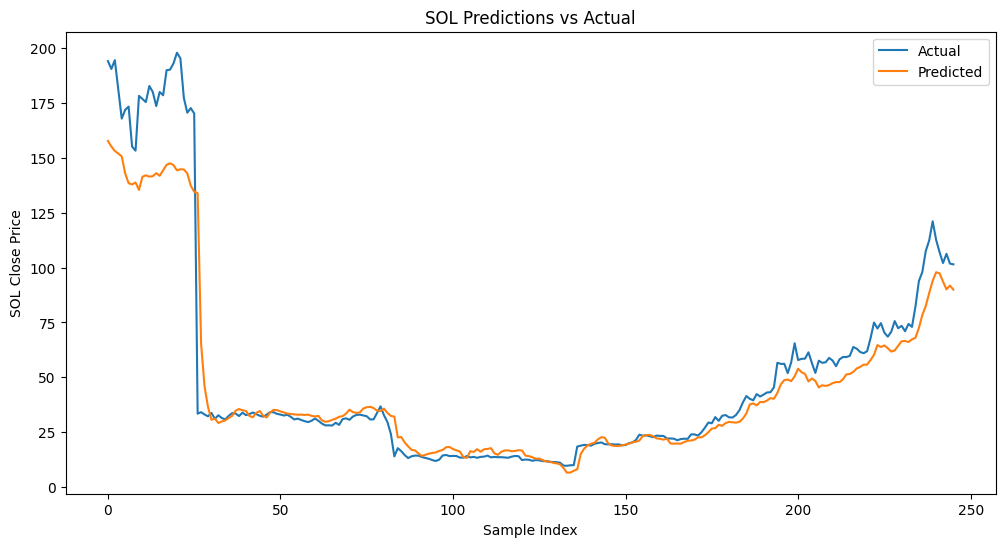

In [32]:
# Plot
plt.figure(figsize=(12,6))
plt.plot(df_sol_plot_year["Actual"], label="Actual")
plt.plot(df_sol_plot_year["Predicted"], label="Predicted")
plt.xlabel("Sample Index")
plt.ylabel("SOL Close Price")
plt.title("SOL Predictions vs Actual")
plt.legend()
plt.show()


## Three quaters split model training

In [33]:
# 75% train / 25% test split (time-based)
q3_split_idx = int(len(sol_X) * 0.75)

sol_q3_X_train = sol_X.iloc[:q3_split_idx].values
sol_q3_X_test  = sol_X.iloc[q3_split_idx:].values

sol_q3_y_train = sol_y.iloc[:q3_split_idx].values
sol_q3_y_test  = sol_y.iloc[q3_split_idx:].values

# Shape checks
print("Q3 SOL X_train shape:", sol_q3_X_train.shape)
print("Q3 SOL X_test shape:", sol_q3_X_test.shape)
print("Q3 SOL y_train shape:", sol_q3_y_train.shape)
print("Q3 SOL y_test shape:", sol_q3_y_test.shape)


Q3 SOL X_train shape: (686, 29)
Q3 SOL X_test shape: (229, 29)
Q3 SOL y_train shape: (686,)
Q3 SOL y_test shape: (229,)


In [34]:
# Assuming sol_df has Date as index
sol_q3_test_dates = sol_df.index[-len(sol_q3_X_test):]

print("Q3 test dates length:", len(sol_q3_test_dates))

Q3 test dates length: 229


In [35]:
from sklearn.preprocessing import MinMaxScaler

# Feature scaler
sol_q3_X_scaler = MinMaxScaler()

# Fit on TRAIN only
sol_q3_X_train_scaled = sol_q3_X_scaler.fit_transform(sol_q3_X_train)

# Transform TEST using same scaler
sol_q3_X_test_scaled = sol_q3_X_scaler.transform(sol_q3_X_test)

print("Q3 Scaled X_train shape:", sol_q3_X_train_scaled.shape)
print("Q3 Scaled X_test shape:", sol_q3_X_test_scaled.shape)

Q3 Scaled X_train shape: (686, 29)
Q3 Scaled X_test shape: (229, 29)


In [36]:
# Target scaler
sol_q3_y_scaler = MinMaxScaler()

# Scale training target
sol_q3_y_train_scaled = sol_q3_y_scaler.fit_transform(
    sol_q3_y_train.reshape(-1, 1)
).flatten()

# Scale test target
sol_q3_y_test_scaled = sol_q3_y_scaler.transform(
    sol_q3_y_test.reshape(-1, 1)
).flatten()


print("Q3 Scaled y_train shape:", sol_q3_y_train_scaled.shape)
print("Q3 Scaled y_test shape:", sol_q3_y_test_scaled.shape)

Q3 Scaled y_train shape: (686,)
Q3 Scaled y_test shape: (229,)


In [37]:
import numpy as np

def create_sequences_q3(X, y, time_steps=30):
    X_seq, y_seq = [], []
    for i in range(len(X) - time_steps):
        X_seq.append(X[i:i + time_steps])
        y_seq.append(y[i + time_steps])
    return np.array(X_seq), np.array(y_seq)

In [38]:
# Create sequences (30-day window)
sol_q3_X_train_seq, sol_q3_y_train_seq = create_sequences_q3(
    sol_q3_X_train_scaled,
    sol_q3_y_train_scaled,
    time_steps=30
)

sol_q3_X_test_seq, sol_q3_y_test_seq = create_sequences_q3(
    sol_q3_X_test_scaled,
    sol_q3_y_test_scaled,
    time_steps=30
)

# Final shape checks
print("Q3 X_train_seq shape:", sol_q3_X_train_seq.shape)
print("Q3 y_train_seq shape:", sol_q3_y_train_seq.shape)
print("Q3 X_test_seq shape:", sol_q3_X_test_seq.shape)
print("Q3 y_test_seq shape:", sol_q3_y_test_seq.shape)

Q3 X_train_seq shape: (656, 30, 29)
Q3 y_train_seq shape: (656,)
Q3 X_test_seq shape: (199, 30, 29)
Q3 y_test_seq shape: (199,)


### Training the model

In [39]:
from Bi_LSTM import BiLSTM, train_model, predict_model

In [40]:
# Get number of features
sol_q3_input_size = sol_q3_X_train_seq.shape[2]

# Initialize model
sol_q3_model = BiLSTM(input_size=sol_q3_input_size)

In [41]:
# Train model
sol_q3_model = train_model(sol_q3_model, sol_q3_X_train_seq, sol_q3_y_train_seq, epochs=50, batch_size=32, lr=0.001)


Epoch [10/50], Loss: 0.005854
Epoch [20/50], Loss: 0.001472
Epoch [30/50], Loss: 0.007639
Epoch [40/50], Loss: 0.008675
Epoch [50/50], Loss: 0.003420


In [42]:
# Generate predictions
sol_q3_preds = predict_model(sol_q3_model, sol_q3_X_test_seq)

print("Q3 Predictions shape:", sol_q3_preds.shape)
print("First 10 Q3 predictions:", sol_q3_preds[:10])


Q3 Predictions shape: (199, 1)
First 10 Q3 predictions: [[0.00765221]
 [0.01252914]
 [0.01660838]
 [0.02037003]
 [0.02164416]
 [0.02695543]
 [0.02834832]
 [0.01922337]
 [0.01689373]
 [0.01902511]]


In [43]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Predict using the Q3 trained model
sol_q3_preds_eval = predict_model(sol_q3_model, sol_q3_X_test_seq)

# Inverse scale predictions to original price values
sol_q3_preds_actual = sol_q3_y_scaler.inverse_transform(
    sol_q3_preds_eval.reshape(-1, 1)
)

# Inverse scale the test targets
sol_q3_y_test_actual = sol_q3_y_scaler.inverse_transform(
    sol_q3_y_test_seq.reshape(-1, 1)
)

# Calculate metrics
sol_q3_mse = mean_squared_error(sol_q3_y_test_actual, sol_q3_preds_actual)
sol_q3_rmse = np.sqrt(sol_q3_mse)
sol_q3_mae = mean_absolute_error(sol_q3_y_test_actual, sol_q3_preds_actual)
sol_q3_r2 = r2_score(sol_q3_y_test_actual, sol_q3_preds_actual)
sol_q3_mape = np.mean(np.abs((sol_q3_y_test_actual - sol_q3_preds_actual) / sol_q3_y_test_actual)) * 100

# Print results
print(f"Q3 MSE: {sol_q3_mse:.2f}")
print(f"Q3 RMSE: {sol_q3_rmse:.2f}")
print(f"Q3 MAE: {sol_q3_mae:.2f}")
print(f"Q3 R2 Score: {sol_q3_r2:.4f}")
print(f"Q3 MAPE: {sol_q3_mape:.2f}%")

Q3 MSE: 170.46
Q3 RMSE: 13.06
Q3 MAE: 10.49
Q3 R2 Score: 0.7197
Q3 MAPE: 27.93%


In [44]:
# Inverse scale predictions
sol_q3_preds_actual = sol_q3_y_scaler.inverse_transform(
    sol_q3_preds.reshape(-1, 1)
)

In [45]:
import pandas as pd
import matplotlib.pyplot as plt

# Align dates and values
sol_q3_dates_seq = sol_df.index[-len(sol_q3_X_test):][30:]
sol_q3_actual_seq = sol_q3_y_test[30:]
sol_q3_pred_seq = sol_q3_preds_actual.flatten()

# Create DataFrame
sol_q3_df_plot = pd.DataFrame({
    "Date": sol_q3_dates_seq,
    "Actual": sol_q3_actual_seq,
    "Predicted": sol_q3_pred_seq
})

sol_q3_df_plot.set_index("Date", inplace=True)
sol_q3_df_plot

,Actual,Predicted
Date,,
2023-06-17,15.650521,11.559344
2023-06-18,15.438235,12.775079
2023-06-19,16.073042,13.791961
2023-06-20,16.635231,14.729676
2023-06-21,17.257046,15.047293
...,...,...
2023-12-28,102.104568,85.393814
2023-12-29,106.311516,80.486511
2023-12-30,101.845085,75.083717


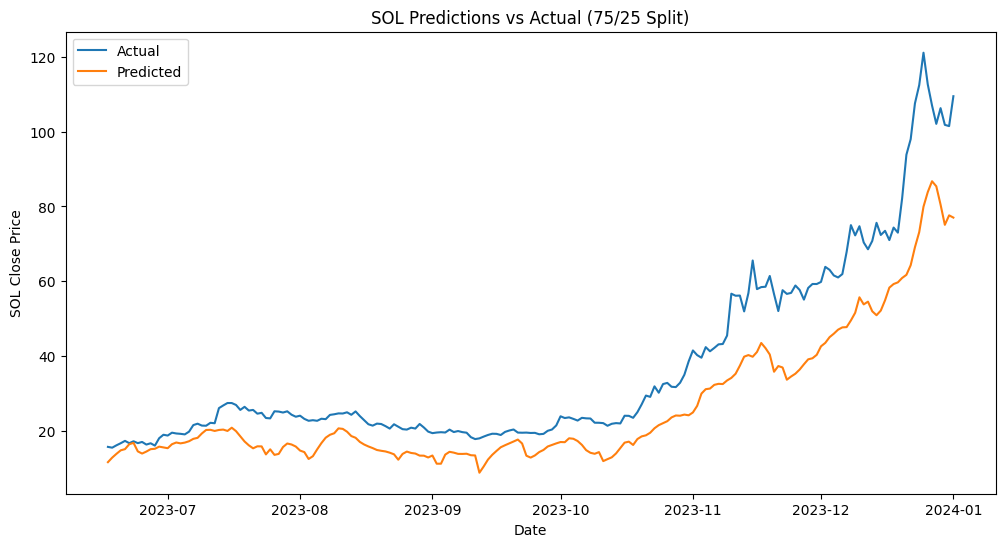

In [46]:
plt.figure(figsize=(12, 6))
plt.plot(sol_q3_df_plot["Actual"], label="Actual")
plt.plot(sol_q3_df_plot["Predicted"], label="Predicted")
plt.xlabel("Date")
plt.ylabel("SOL Close Price")
plt.title("SOL Predictions vs Actual (75/25 Split)")
plt.legend()
plt.show()

## Saving the best model (out of accuracy) for Solana

In [47]:
# import joblib
# joblib.dump(sol_q3_model, "Solana_base_model.pkl")

# Finetuning the models using optuna

In [48]:
import optuna

c:\Users\tharu\anaconda3\envs\Streamlit\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [49]:
from sklearn.model_selection import train_test_split

sol_q3_X_train_tune, sol_q3_X_val_tune, sol_q3_y_train_tune, sol_q3_y_val_tune = train_test_split(
    sol_q3_X_train_seq,
    sol_q3_y_train_seq,
    test_size=0.2,
    shuffle=False
)

In [51]:
import torch
import numpy as np

def objective(trial):

    # Hyperparameters to tune
    hidden_size = trial.suggest_int("hidden_size", 32, 128)
    num_layers = trial.suggest_int("num_layers", 1, 3)
    lr = trial.suggest_loguniform("lr", 1e-4, 1e-2)
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64])

    # Get input size
    input_size = sol_q3_X_train_tune.shape[2]

    # Create model
    model = BiLSTM(
        input_size=input_size,
        hidden_size=hidden_size,
        num_layers=num_layers
    )

    # Train model
    model = train_model(
        model,
        sol_q3_X_train_tune,
        sol_q3_y_train_tune,
        epochs=30,
        batch_size=batch_size,
        lr=lr
    )

    # Validation prediction
    preds = predict_model(model, sol_q3_X_val_tune)

    # Calculate validation MSE
    val_loss = np.mean((preds.flatten() - sol_q3_y_val_tune) ** 2)

    return val_loss

In [52]:
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=10)

[I 2026-03-15 18:52:09,184] A new study created in memory with name: no-name-992b63c5-a0a6-47bc-a69e-5b4f9bf3890c
C:\Users\tharu\AppData\Local\Temp\ipykernel_20536\1950460389.py:9: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  lr = trial.suggest_loguniform("lr", 1e-4, 1e-2)


Epoch [10/30], Loss: 0.002415
Epoch [20/30], Loss: 0.001819


[I 2026-03-15 18:52:21,312] Trial 0 finished with value: 0.00039330162638206366 and parameters: {'hidden_size': 98, 'num_layers': 1, 'lr': 0.001168042153259778, 'batch_size': 64}. Best is trial 0 with value: 0.00039330162638206366.


Epoch [30/30], Loss: 0.001700
Epoch [10/30], Loss: 0.003152
Epoch [20/30], Loss: 0.005125


[I 2026-03-15 18:53:09,730] Trial 1 finished with value: 0.0004720926004676422 and parameters: {'hidden_size': 99, 'num_layers': 2, 'lr': 0.0012538398109728714, 'batch_size': 16}. Best is trial 0 with value: 0.00039330162638206366.


...

Epoch [30/30], Loss: 0.006206
Epoch [10/30], Loss: 0.006160
Epoch [20/30], Loss: 0.002384


[I 2026-03-15 18:56:41,315] Trial 8 finished with value: 0.00040494643327631304 and parameters: {'hidden_size': 117, 'num_layers': 2, 'lr': 0.0002465462727951438, 'batch_size': 16}. Best is trial 3 with value: 0.00010399629484513722.


Epoch [30/30], Loss: 0.001857
Epoch [10/30], Loss: 0.003535
Epoch [20/30], Loss: 0.002828


[I 2026-03-15 18:59:22,696] Trial 9 finished with value: 0.0003333123517505163 and parameters: {'hidden_size': 110, 'num_layers': 3, 'lr': 0.00016425478795475712, 'batch_size': 16}. Best is trial 3 with value: 0.00010399629484513722.


Epoch [30/30], Loss: 0.003520


In [53]:
print(study.best_params)

{'hidden_size': 116, 'num_layers': 1, 'lr': 0.006504254706448316, 'batch_size': 16}


In [54]:
import optuna.visualization as vis

vis.plot_optimization_history(study)

In [55]:
vis.plot_param_importances(study)

In [56]:
vis.plot_parallel_coordinate(study)

### Testing new parameters

In [57]:
# Best parameters from Optuna
best_params = study.best_params

# Get input size
input_size = sol_q3_X_train_seq.shape[2]

# Create final tuned model
model_tuned = BiLSTM(
    input_size=input_size,
    hidden_size=best_params["hidden_size"],
    num_layers=best_params["num_layers"]
)

# Train final model on full training data
model_tuned = train_model(
    model_tuned,
    sol_q3_X_train_seq,
    sol_q3_y_train_seq,
    epochs=50,
    batch_size=best_params["batch_size"],
    lr=best_params["lr"]
)

Epoch [10/50], Loss: 0.002710
Epoch [20/50], Loss: 0.002821
Epoch [30/50], Loss: 0.001917
Epoch [40/50], Loss: 0.004181
Epoch [50/50], Loss: 0.003065


In [58]:
sol_preds_tuned = predict_model(model_tuned, sol_q3_X_test_seq)
sol_preds_tuned[:10]

array([[0.02136268],
       [0.01960318],
       [0.01980726],
       [0.0171728 ],
       [0.01733036],
       [0.02527258],
       [0.02424966],
       [0.01207618],
       [0.01616921],
       [0.01166637]], dtype=float32)

In [59]:
sol_preds_tuned_actual = sol_q3_y_scaler.inverse_transform(sol_preds_tuned.reshape(-1,1))

In [66]:
sol_y_test_actual = y_scaler.inverse_transform(sol_y_test_seq.reshape(-1,1))

In [67]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

mse = mean_squared_error(sol_q3_y_test_actual, sol_preds_tuned_actual)
rmse = np.sqrt(mse)
mae = mean_absolute_error(sol_q3_y_test_actual, sol_preds_tuned_actual)
r2 = r2_score(sol_q3_y_test_actual, sol_preds_tuned_actual)
mape = np.mean(np.abs((sol_q3_y_test_actual - sol_preds_tuned_actual) / sol_q3_y_test_actual)) * 100

print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R2 Score: {r2:.4f}")
print(f"MAPE: {mape:.2f}%")

MSE: 229.62
RMSE: 15.15
MAE: 13.28
R2 Score: 0.6224
MAPE: 40.48%
